In [66]:
import os
import numpy as np
import time
from itertools import product
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from cpg_rbf.cpg_so2 import CPG_SO2
from cpg_rbf.rbf import RBF
from cpg_rbf.cpg_so2 import CPG_LOCO
from cpg_rbf.dual_learner import DIL

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [67]:
from scipy.interpolate import interp1d
# resample target
def resample_cycle(cycle, num_points):
    """Resamples a gait cycle to have a fixed number of points using interpolation."""
    original_indices = np.linspace(0, 1, len(cycle))  # original indices based on the length of the cycle
    new_indices = np.linspace(0, 1, num_points)  # new indices to match the desired number of points
    interpolation_function = interp1d(original_indices, cycle, kind='linear')  # interpolate the data
    return interpolation_function(new_indices)  # return the resampled cycle

In [ ]:
rbf = RBF()
cpg = CPG_SO2()

target_length = 10000

# It would be centerize the kernel first
cpg_one_cycle = cpg.generate_cpg_one_cycle(0.05)       # lowest phi value
out0_cpg_one_cycle = cpg_one_cycle['out0_cpg_one_cycle'][:] # Use full cycle of CPG
out1_cpg_one_cycle = cpg_one_cycle['out1_cpg_one_cycle'][:] # Use full cycle of CPG
cpg_cycle_length = len(out0_cpg_one_cycle)
rbf_kernels = rbf.construct_kernels_with_cpg_one_cycle(out0_cpg_one_cycle, out1_cpg_one_cycle, cpg_cycle_length) # construct kernels with cpg one cycle

✅ PCA Plot successfully saved to: gait_weights_pca_comparison.png


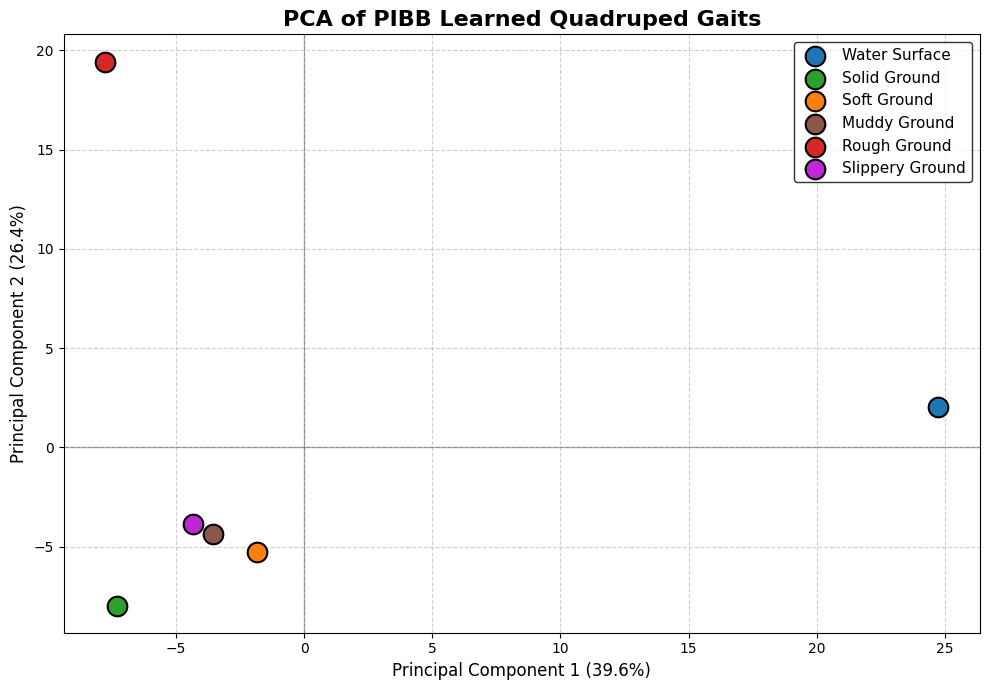

In [5]:
import json
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ======================================================
# 1. CONFIGURATION: Define your gaits
# ======================================================
# Update these paths to match the exact folder names inside 'learned_weight_set'
weight_files = {
    'Water Surface': {
        'filepath': 'learned_weight_set/water_surface_new/learned_weights.json',
        'color': '#1f77b4',  # Blue
        'marker': 'o'
    },
    'Solid Ground': {
        'filepath': 'learned_weight_set/solid_ground/learned_weights.json',
        'color': '#2ca02c',  # Green
        'marker': 'o'
    },
    'Soft Ground': {
        'filepath': 'learned_weight_set/soft_ground/learned_weights.json',
        'color': '#ff7f0e',  # Orange
        'marker': 'o'
    },
    'Muddy Ground': {
        'filepath': 'learned_weight_set/muddy_ground/learned_weights.json',
        'color': '#8c564b',  # Brown
        'marker': 'o'
    },
    'Rough Ground': {
        'filepath': 'learned_weight_set/rough_ground/learned_weights.json',
        'color': '#d62728',  # Red
        'marker': 'o'
    },
    'Slippery Ground': {
        'filepath': 'learned_weight_set/slippery_ground/learned_weights.json',
        'color': "#bf27d6",  # Red
        'marker': 'o'
    }
}

all_features = []
labels = []
colors = []
markers = []

# ======================================================
# 2. LOAD AND FLATTEN JSON WEIGHTS
# ======================================================
for label, meta in weight_files.items():
    filepath = meta['filepath']
    
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found. Skipping...")
        continue

    # Load JSON file
    with open(filepath, "r") as f:
        raw_learned_weights = json.load(f)
        
    # 🚨 CRITICAL: Sort the keys alphabetically! 
    # This guarantees that 'BL0' is always compared to 'BL0', etc.
    sorted_keys = sorted(raw_learned_weights.keys())
    
    # Extract the arrays in the sorted order and flatten them
    flat_components = [np.array(raw_learned_weights[key]).ravel() for key in sorted_keys]
    
    # Combine all 320 parameters into one long 1D feature vector for PCA
    weight_vector = np.concatenate(flat_components)
    
    all_features.append(weight_vector)
    labels.append(label)
    colors.append(meta['color'])
    markers.append(meta['marker'])

# Check if we have enough data points
if len(all_features) < 2:
    raise ValueError("Need at least 2 valid JSON weight sets to perform PCA.")

X = np.array(all_features)

# ======================================================
# 3. STANDARDIZE & PCA
# ======================================================
# Standardize features (Mean=0, Variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
n_components = min(2, X.shape[0]) 
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# ======================================================
# 4. PLOTTING
# ======================================================
plt.figure(figsize=(10, 7))

# If we have 2 dimensions to plot (at least 2 valid files loaded)
if n_components >= 2:
    for i in range(len(labels)):
        plt.scatter(
            X_pca[i, 0], X_pca[i, 1], 
            color=colors[i], 
            marker=markers[i], 
            s=200,  # Marker size
            edgecolors='black', 
            linewidths=1.5,
            label=labels[i],
            zorder=3
        )
    
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title('PCA of PIBB Learned Quadruped Gaits', fontsize=16, fontweight='bold')
    
else:
    # Fallback to 1D plot if only 2 data points exist (PCA collapses to 1 line)
    for i in range(len(labels)):
        plt.scatter(X_pca[i, 0], np.zeros_like(X_pca[i, 0]), 
                    color=colors[i], marker=markers[i], s=200, edgecolors='black', label=labels[i])
    plt.xlabel('Principal Component 1', fontsize=12)
    plt.title('1D PCA Projection of Gaits', fontsize=16, fontweight='bold')

# Formatting
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)
plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.axvline(0, color='black', linewidth=1, alpha=0.3)
plt.legend(frameon=True, facecolor='white', edgecolor='black', fontsize=11, loc='best')
plt.tight_layout()

# Save and show
save_path = 'gait_weights_pca_comparison.png'
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ PCA Plot successfully saved to: {save_path}")

plt.show()

## Switching Gaits

Simulating temporal gait transitions...
✅ Trajectory plot successfully saved to: adaptive_locomotion_trajectory_BR0.png


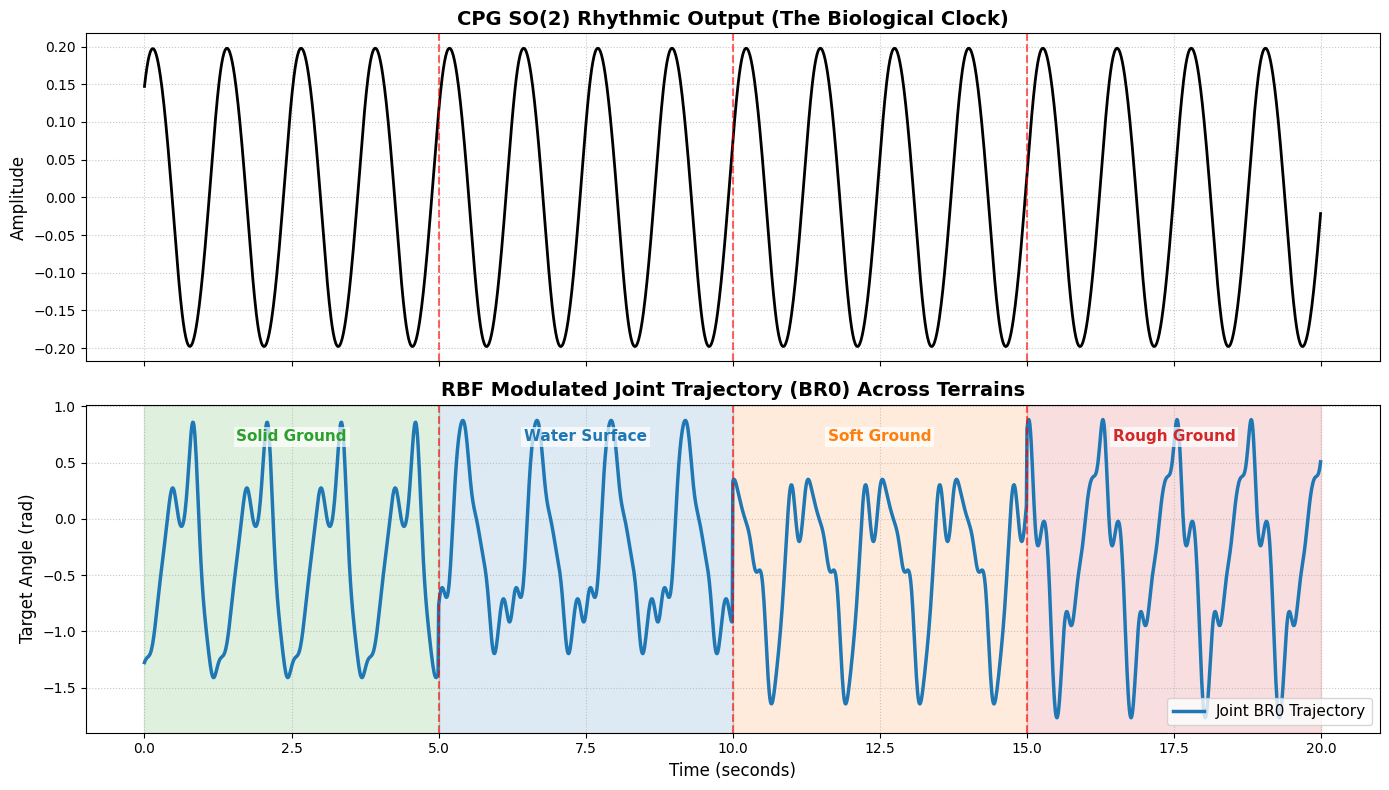

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Assuming these are available in your workspace
from cpg_rbf.cpg_so2 import CPG_SO2, CPG_LOCO
from cpg_rbf.rbf import RBF

# ======================================================
# 1. HELPER: LOAD JSON WEIGHTS
# ======================================================
def load_json_weights(filepath):
    """Loads a JSON weight file and converts all lists to NumPy arrays."""
    try:
        with open(filepath, 'r') as f:
            raw_weights = json.load(f)
        return {k: np.array(v) for k, v in raw_weights.items()}
    except FileNotFoundError:
        print(f"Error: {filepath} not found. Ensure the path is correct.")
        return None

# Load the weights for 4 distinct environments
# (Update these paths if your folder names differ!)
weights_solid_ground = load_json_weights('learned_weight_set/solid_ground/learned_weights.json')
weights_water_pool   = load_json_weights('learned_weight_set/water_surface/learned_weights.json')
weights_soft_ground  = load_json_weights('learned_weight_set/soft_ground/learned_weights.json')
weights_rough_ground = load_json_weights('learned_weight_set/rough_ground/learned_weights.json')

# We will track a single joint (e.g., Back-Right Hip)
JOINT_TO_TRACK = 'BR0'

# ======================================================
# 2. INITIALIZE NEURAL NETWORKS (Required for RBF to work)
# ======================================================
NUM_KERNELS = 20
CPG_PHI = 0.05

cpg = CPG_SO2()
rbf = RBF(nc=NUM_KERNELS)

# Generate baseline cycle to construct the kernels
cpg_one_cycle = cpg.generate_cpg_one_cycle(CPG_PHI)
rbf.construct_kernels_with_cpg_one_cycle(
    cpg_one_cycle['out0_cpg_one_cycle'][:], 
    cpg_one_cycle['out1_cpg_one_cycle'][:], 
    len(cpg_one_cycle['out0_cpg_one_cycle'][:])
)

# ======================================================
# 3. SIMULATION LOOP SETUP
# ======================================================
cpg_modulated = CPG_LOCO()

cpg_output_list = []
traj_output_list = []
time_list = []

duration    = 20.0              # seconds
frequency   = 100               # Hz
dt          = 1.0 / frequency   # 0.01 seconds
total_steps = int(duration * frequency)

print("Simulating temporal gait transitions...")

for step in range(total_steps):
    sim_time = step * dt

    # Step the CPG forward
    cpg_output_t = cpg_modulated.modulate_cpg(CPG_PHI, 0.0, 1.0)

    # --------------------------------------------------
    # GAIT SWITCHING LOGIC
    # --------------------------------------------------
    if sim_time < 5.0:
        active_weights = weights_solid_ground
    elif sim_time < 10.0:
        active_weights = weights_water_pool
    elif sim_time < 15.0:
        active_weights = weights_soft_ground
    else:
        active_weights = weights_rough_ground
        
    # Generate the target joint angle using the active weights
    if active_weights is not None:
        traj_output_t = rbf.regenerate_target_traj(
            cpg_output_t['cpg_output_0'], 
            cpg_output_t['cpg_output_1'], 
            active_weights[JOINT_TO_TRACK]
        )
    else:
        traj_output_t = 0.0 # Fallback if file failed to load

    # Store data for plotting
    traj_output_list.append(traj_output_t)
    cpg_output_list.append(cpg_output_t['cpg_output_0'])
    time_list.append(sim_time)

# ======================================================
# 4. PLOTTING THE TRANSITIONS
# ======================================================
fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Plot 1: The Underlying CPG Oscillator ---
axs[0].plot(time_list, cpg_output_list, color='black', linewidth=2)
axs[0].set_title('CPG SO(2) Rhythmic Output (The Biological Clock)', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Amplitude', fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.7)

# --- Plot 2: The Modulated RBF Trajectory ---
axs[1].plot(time_list, traj_output_list, color='#1f77b4', linewidth=2.5, label=f'Joint {JOINT_TO_TRACK} Trajectory')
axs[1].set_title(f'RBF Modulated Joint Trajectory ({JOINT_TO_TRACK}) Across Terrains', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Time (seconds)', fontsize=12)
axs[1].set_ylabel('Target Angle (rad)', fontsize=12)
axs[1].grid(True, linestyle=':', alpha=0.7)

# --- Add Shaded Background Regions to indicate gaits ---
regions = [
    (0.0, 5.0, 'Solid Ground', '#2ca02c'),    # Green
    (5.0, 10.0, 'Water Surface', '#1f77b4'),  # Blue
    (10.0, 15.0, 'Soft Ground', '#ff7f0e'),   # Orange
    (15.0, 20.0, 'Rough Ground', '#d62728')   # Red
]

for start_t, end_t, label, color in regions:
    # Add shaded background to the bottom plot
    axs[1].axvspan(start_t, end_t, color=color, alpha=0.15, label='_nolegend_')
    
    # Add transition lines to both plots
    if start_t > 0:
        axs[0].axvline(x=start_t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
        axs[1].axvline(x=start_t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
        
    # Add text labels at the top of the trajectory plot
    axs[1].text(start_t + 2.5, max(traj_output_list) * 0.9, label, 
                fontsize=11, fontweight='bold', color=color, 
                ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

axs[1].legend(loc='lower right', fontsize=11)
plt.tight_layout()

# Save and show
save_path = f'adaptive_locomotion_trajectory_{JOINT_TO_TRACK}.png'
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"✅ Trajectory plot successfully saved to: {save_path}")

plt.show()

## Change Gaits

Simulating transitions and collecting weight history...
Calculating 2D and 3D PCA on weight transitions...
✅ All 3 plots successfully generated and saved!


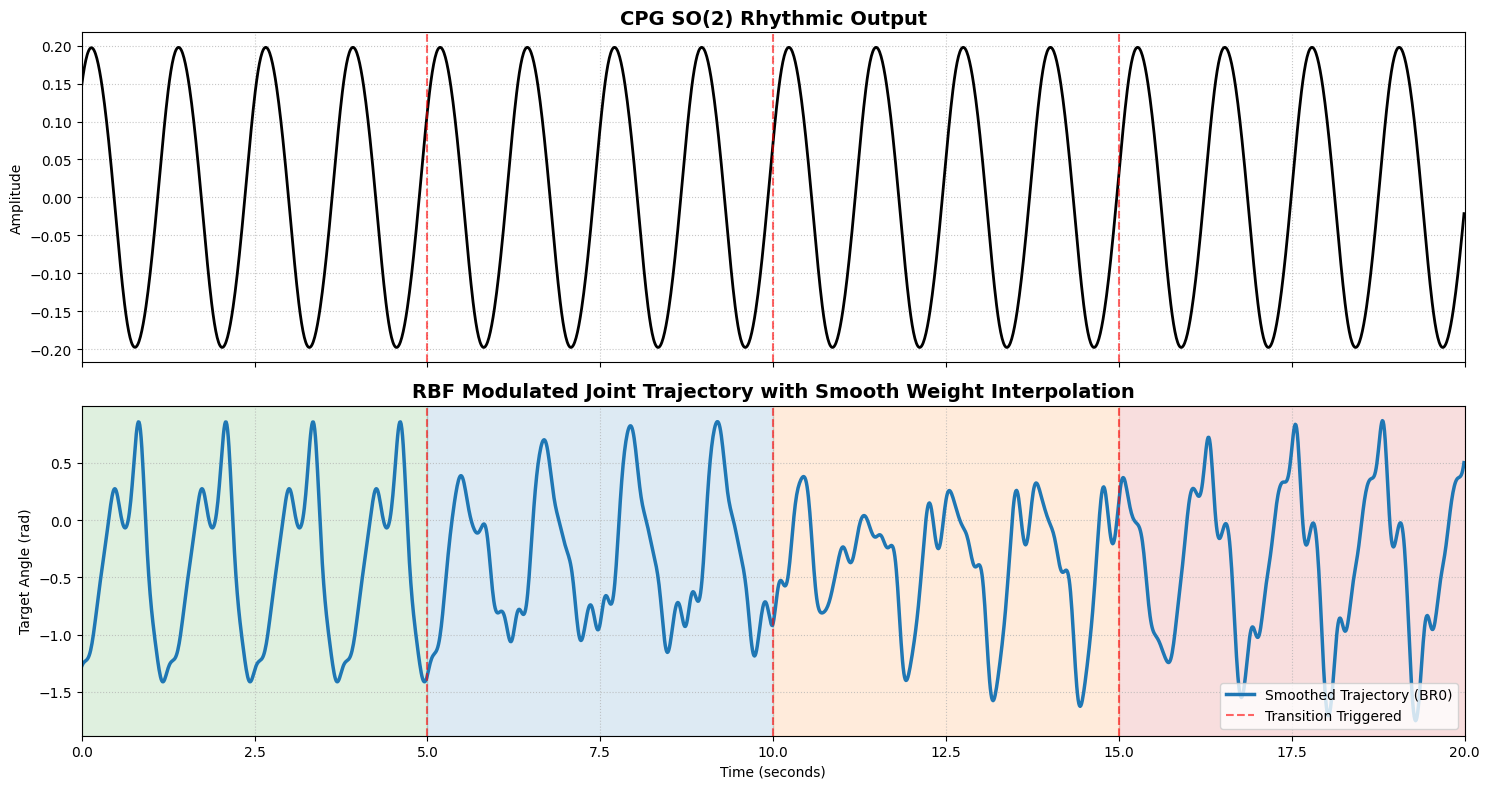

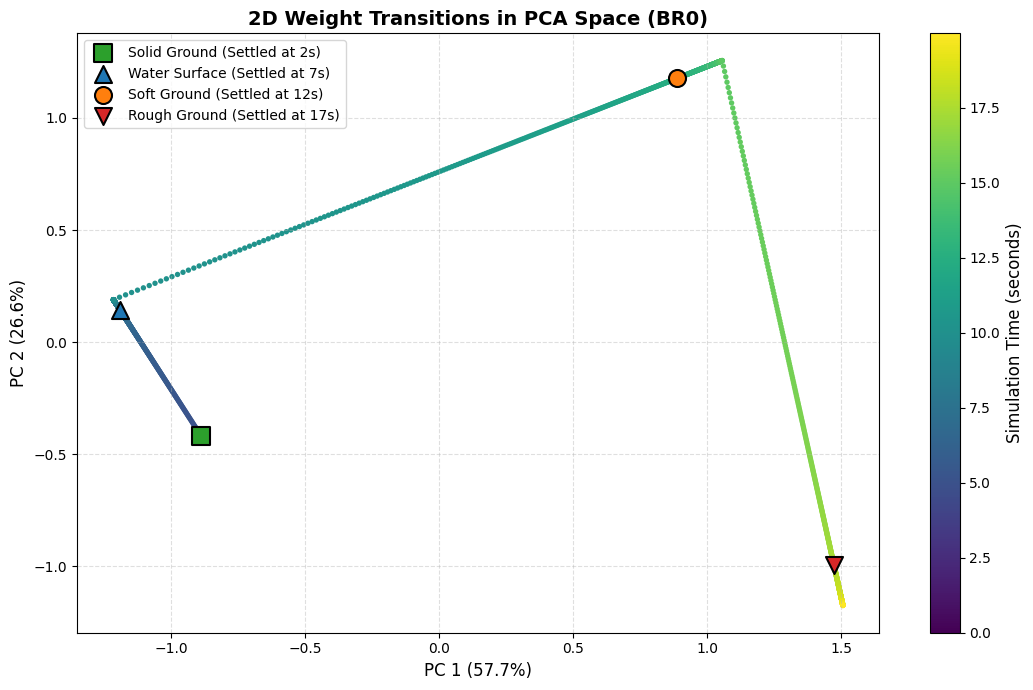

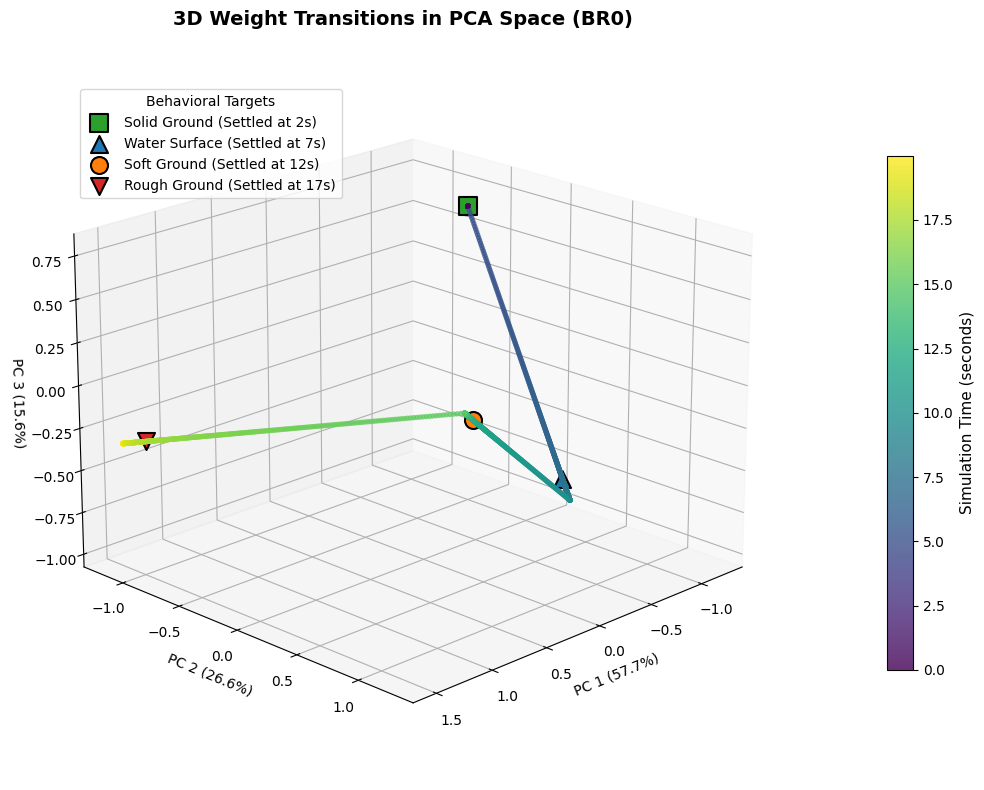

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Assuming these are available in your workspace
from cpg_rbf.cpg_so2 import CPG_SO2, CPG_LOCO
from cpg_rbf.rbf import RBF

# ======================================================
# 1. HELPER: LOAD JSON WEIGHTS
# ======================================================
def load_json_weights(filepath):
    try:
        with open(filepath, 'r') as f:
            raw_weights = json.load(f)
        return {k: np.array(v) for k, v in raw_weights.items()}
    except FileNotFoundError:
        print(f"Error: {filepath} not found.")
        return None

# Load the weights for 4 distinct environments
weights_solid = load_json_weights('learned_weight_set/solid_ground/learned_weights.json')
weights_water = load_json_weights('learned_weight_set/water_surface/learned_weights.json')
weights_soft  = load_json_weights('learned_weight_set/soft_ground/learned_weights.json')
weights_rough = load_json_weights('learned_weight_set/rough_ground/learned_weights.json')

JOINT_TO_TRACK = 'BR0'

# ======================================================
# 2. INITIALIZE NEURAL NETWORKS
# ======================================================
NUM_KERNELS = 20
CPG_PHI = 0.05

cpg = CPG_SO2()
rbf = RBF(nc=NUM_KERNELS)

cpg_one_cycle = cpg.generate_cpg_one_cycle(CPG_PHI)
rbf.construct_kernels_with_cpg_one_cycle(
    cpg_one_cycle['out0_cpg_one_cycle'][:], 
    cpg_one_cycle['out1_cpg_one_cycle'][:], 
    len(cpg_one_cycle['out0_cpg_one_cycle'][:])
)

# ======================================================
# 3. SIMULATION LOOP (With Smoothing & Tracking)
# ======================================================
cpg_modulated = CPG_LOCO()

time_list = []
cpg_output_list = []
traj_output_list = []
rbf_weight_list = []  

duration    = 20.0          
frequency   = 100       
dt          = 1.0 / frequency   
total_steps = int(duration * frequency)

rbf_weight_prev = np.copy(weights_solid[JOINT_TO_TRACK])
SMOOTHING_FACTOR = 0.01

print("Simulating transitions and collecting weight history...")

for step in range(total_steps):
    sim_time = step * dt
    cpg_output_t = cpg_modulated.modulate_cpg(CPG_PHI, 0.0, 1.0)

    # GAIT TARGET SELECTION
    if sim_time < 5.0:
        rbf_weight_target = weights_solid[JOINT_TO_TRACK]
    elif sim_time < 10.0:
        rbf_weight_target = weights_water[JOINT_TO_TRACK]
    elif sim_time < 15.0:
        rbf_weight_target = weights_soft[JOINT_TO_TRACK]
    else:
        rbf_weight_target = weights_rough[JOINT_TO_TRACK]
        
    # SMOOTH WEIGHT INTERPOLATION
    rbf_weight_t = rbf_weight_prev + (rbf_weight_target - rbf_weight_prev) * SMOOTHING_FACTOR
    
    # Generate Target Trajectory
    traj_output_t = rbf.regenerate_target_traj(
        cpg_output_t['cpg_output_0'], 
        cpg_output_t['cpg_output_1'], 
        rbf_weight_t
    )

    rbf_weight_prev = np.copy(rbf_weight_t)

    # STORE DATA (np.copy is CRITICAL)
    time_list.append(sim_time)
    cpg_output_list.append(cpg_output_t['cpg_output_0'])
    traj_output_list.append(traj_output_t)
    rbf_weight_list.append(np.copy(rbf_weight_t))

# ======================================================
# 4. PLOT 1: TIME SERIES TRAJECTORY
# ======================================================
fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axs[0].plot(time_list, cpg_output_list, color='black', linewidth=2)
axs[0].set_title('CPG SO(2) Rhythmic Output', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True, linestyle=':', alpha=0.7)
axs[0].set_xlim(0, duration)

axs[1].plot(time_list, traj_output_list, color='#1f77b4', linewidth=2.5, label=f'Smoothed Trajectory ({JOINT_TO_TRACK})')
axs[1].set_title(f'RBF Modulated Joint Trajectory with Smooth Weight Interpolation', fontsize=14, fontweight='bold')
axs[1].set_xlabel('Time (seconds)')
axs[1].set_ylabel('Target Angle (rad)')
axs[1].grid(True, linestyle=':', alpha=0.7)

regions = [
    (0.0, 5.0, 'Solid Ground Target', '#2ca02c'),    
    (5.0, 10.0, 'Water Surface Target', '#1f77b4'),  
    (10.0, 15.0, 'Soft Ground Target', '#ff7f0e'),   
    (15.0, 20.0, 'Rough Ground Target', '#d62728')   
]

for start_t, end_t, label, color in regions:
    axs[1].axvspan(start_t, end_t, color=color, alpha=0.15, label='_nolegend_')
    if start_t > 0:
        axs[0].axvline(x=start_t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
        lbl = 'Transition Triggered' if start_t == 5.0 else ""
        axs[1].axvline(x=start_t, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label=lbl)

axs[1].legend(loc='lower right')
plt.tight_layout()
# plt.savefig(f'adaptive_trajectory_smoothed_{JOINT_TO_TRACK}.png', dpi=300, bbox_inches='tight')

# ======================================================
# 5. PLOT 2 & 3 SHARED DATA PREP
# ======================================================
# Styling dictionary synced to your environments
pca_styles = {
    'Solid Ground':  {'color': '#2ca02c', 'marker': 's'},
    'Water Surface': {'color': '#1f77b4', 'marker': '^'},
    'Soft Ground':   {'color': '#ff7f0e', 'marker': 'o'},
    'Rough Ground':  {'color': '#d62728', 'marker': 'v'}
}

rbf_weights_matrix = np.array(rbf_weight_list)
time_np = np.array(time_list)
transitions = [
    (2.5, 'Solid Ground'),
    (7.5, 'Water Surface'),
    (12.5, 'Soft Ground'),
    (17.5, 'Rough Ground')
]

# ======================================================
# 6. PLOT 2: 2D PCA TEMPORAL TRANSITION
# ======================================================
print("Calculating 2D and 3D PCA on weight transitions...")
pca_2d = PCA(n_components=2)
rbf_pca_2d = pca_2d.fit_transform(rbf_weights_matrix)

plt.figure(figsize=(11, 7))
scatter_2d = plt.scatter(rbf_pca_2d[:, 0], rbf_pca_2d[:, 1], c=time_list, cmap='viridis', s=15, alpha=1.0, edgecolors='none')

for t, label in transitions:
    idx = np.abs(time_np - t).argmin()
    plt.scatter(
        rbf_pca_2d[idx, 0], rbf_pca_2d[idx, 1], 
        color=pca_styles[label]['color'], edgecolors='black', linewidths=1.5,
        s=150, marker=pca_styles[label]['marker'], zorder=5, label=f"{label} (Settled at {int(t)}s)"
    )

cbar_2d = plt.colorbar(scatter_2d)
cbar_2d.set_label('Simulation Time (seconds)', fontsize=12)
plt.xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title(f'2D Weight Transitions in PCA Space ({JOINT_TO_TRACK})', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, facecolor='white', loc='best', fontsize=10)
plt.tight_layout()
# plt.savefig(f'rbf_weights_pca_2d_{JOINT_TO_TRACK}.png', dpi=300, bbox_inches='tight')

# ======================================================
# 7. PLOT 3: 3D PCA TEMPORAL TRANSITION
# ======================================================
pca_3d = PCA(n_components=3)
rbf_pca_3d = pca_3d.fit_transform(rbf_weights_matrix)

fig_3d = plt.figure(figsize=(12, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

scatter_3d = ax_3d.scatter(
    rbf_pca_3d[:, 0], rbf_pca_3d[:, 1], rbf_pca_3d[:, 2],
    c=time_list, cmap='viridis', s=15, alpha=0.8, edgecolors='none'
)

cbar_3d = plt.colorbar(scatter_3d, ax=ax_3d, pad=0.1, shrink=0.7)
cbar_3d.set_label('Simulation Time (seconds)', fontsize=11)

for t, label in transitions:
    idx = np.abs(time_np - t).argmin()
    color = pca_styles[label]['color']
    marker_symbol = pca_styles[label]['marker']
    
    ax_3d.scatter(
        rbf_pca_3d[idx, 0], rbf_pca_3d[idx, 1], rbf_pca_3d[idx, 2],
        color=color, marker=marker_symbol, s=150, edgecolors='black', 
        linewidths=1.5, alpha=1.0, zorder=5, label=f"{label} (Settled at {int(t)}s)"
    )

evr = pca_3d.explained_variance_ratio_ * 100
ax_3d.set_xlabel(f'PC 1 ({evr[0]:.1f}%)', fontsize=10)
ax_3d.set_ylabel(f'PC 2 ({evr[1]:.1f}%)', fontsize=10)
ax_3d.set_zlabel(f'PC 3 ({evr[2]:.1f}%)', fontsize=10)
ax_3d.set_title(f'3D Weight Transitions in PCA Space ({JOINT_TO_TRACK})', fontsize=14, fontweight='bold', pad=15)
ax_3d.view_init(elev=20, azim=45) 

ax_3d.legend(
    title="Behavioral Targets", frameon=True, facecolor='white', 
    loc='upper left', bbox_to_anchor=(0.05, 0.95), fontsize=10
)

plt.tight_layout()
# plt.savefig(f'rbf_weights_pca_3d_{JOINT_TO_TRACK}.png', dpi=300, bbox_inches='tight')

print("✅ All 3 plots successfully generated and saved!")
plt.show()

## Change Gaits (Kernel Masking)

### Kernel plot

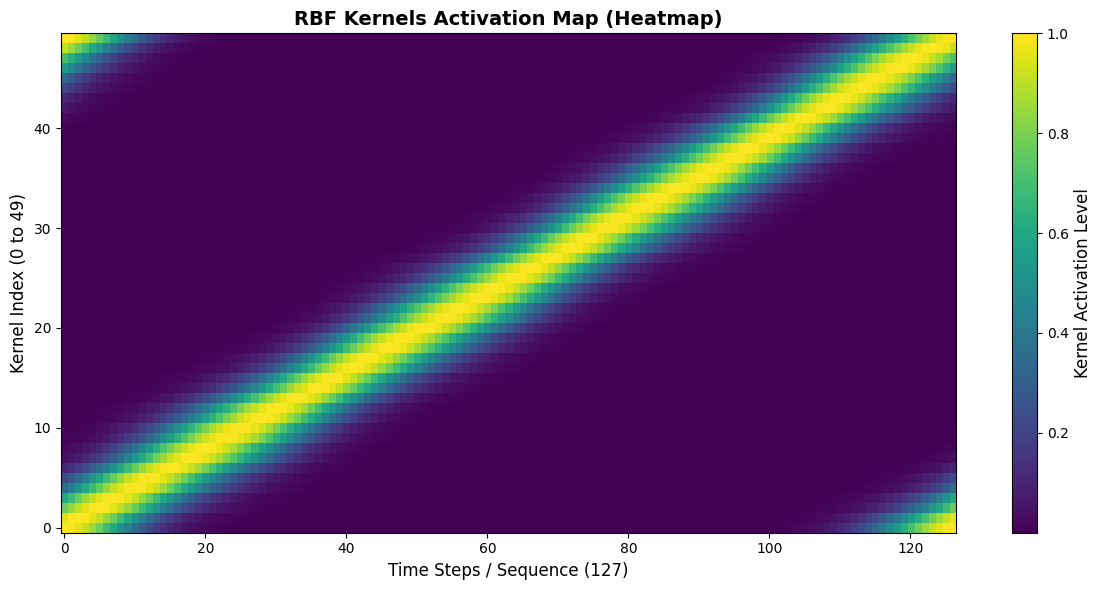

In [75]:
# Assuming 'rbf_kernels' is your (50, 127) numpy array
plt.figure(figsize=(12, 6))

# imshow is perfect for 2D matrices
# aspect='auto' ensures it stretches nicely to fit the 12x6 figure
# origin='lower' puts kernel 0 at the bottom of the y-axis
im = plt.imshow(rbf_kernels, aspect='auto', cmap='viridis', origin='lower')

# Add a colorbar to show the scale (0.0 to 1.0)
cbar = plt.colorbar(im)
cbar.set_label('Kernel Activation Level', fontsize=12)

plt.xlabel('Time Steps / Sequence (127)', fontsize=12)
plt.ylabel('Kernel Index (0 to 49)', fontsize=12)
plt.title('RBF Kernels Activation Map (Heatmap)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

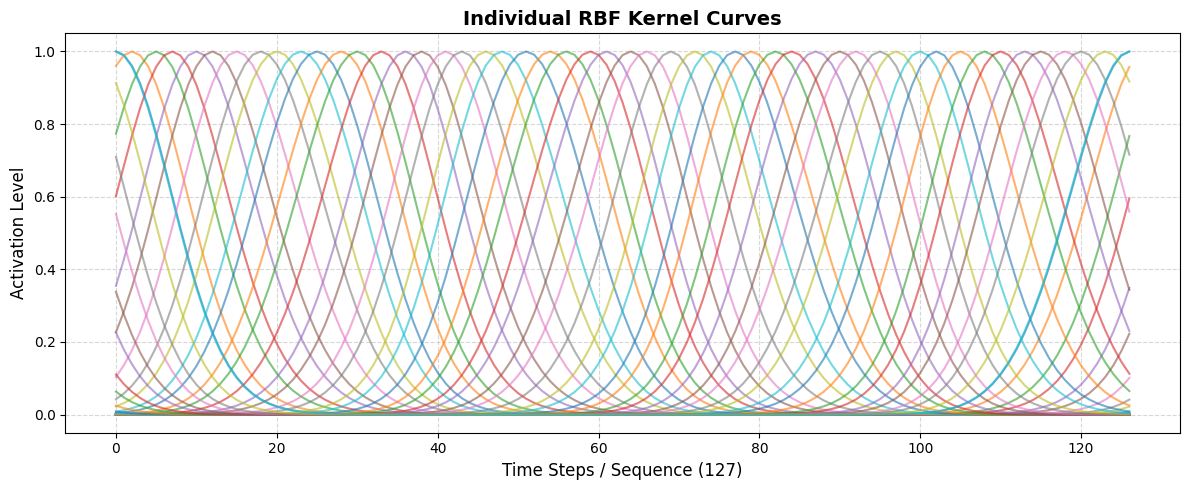

In [76]:

plt.figure(figsize=(12, 5))

# Loop through each of the 50 kernels and plot its 127 values
# We use alpha=0.6 to make the lines slightly transparent so overlapping curves are visible
for i in range(rbf_kernels.shape[0]):
    plt.plot(rbf_kernels[i, :], alpha=0.6, linewidth=1.5)

plt.xlabel('Time Steps / Sequence (127)', fontsize=12)
plt.ylabel('Activation Level', fontsize=12)
plt.title('Individual RBF Kernel Curves', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Set y-limits if you know your activations are strictly between 0 and 1
plt.ylim(-0.05, 1.05) 

plt.tight_layout()
plt.show()

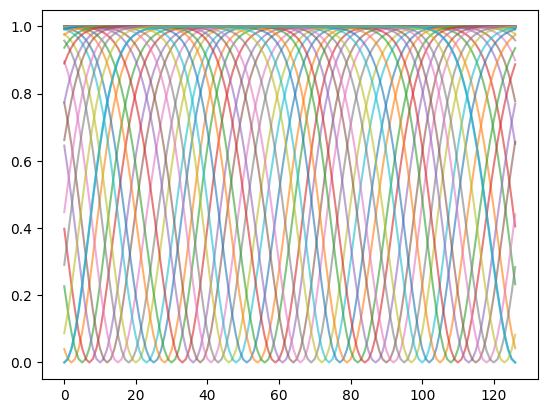

In [77]:
new_kernel = []
for i in range(rbf_kernels.shape[0]):
    new_kernel.append(1 - rbf_kernels[i, :])
    plt.plot(new_kernel[i], alpha=0.6, linewidth=1.5)

### Loop

Simulating transitions using smooth gated trajectory...
Calculating 2D and 3D PCA on weight transitions...
✅ All 3 plots successfully generated and saved!


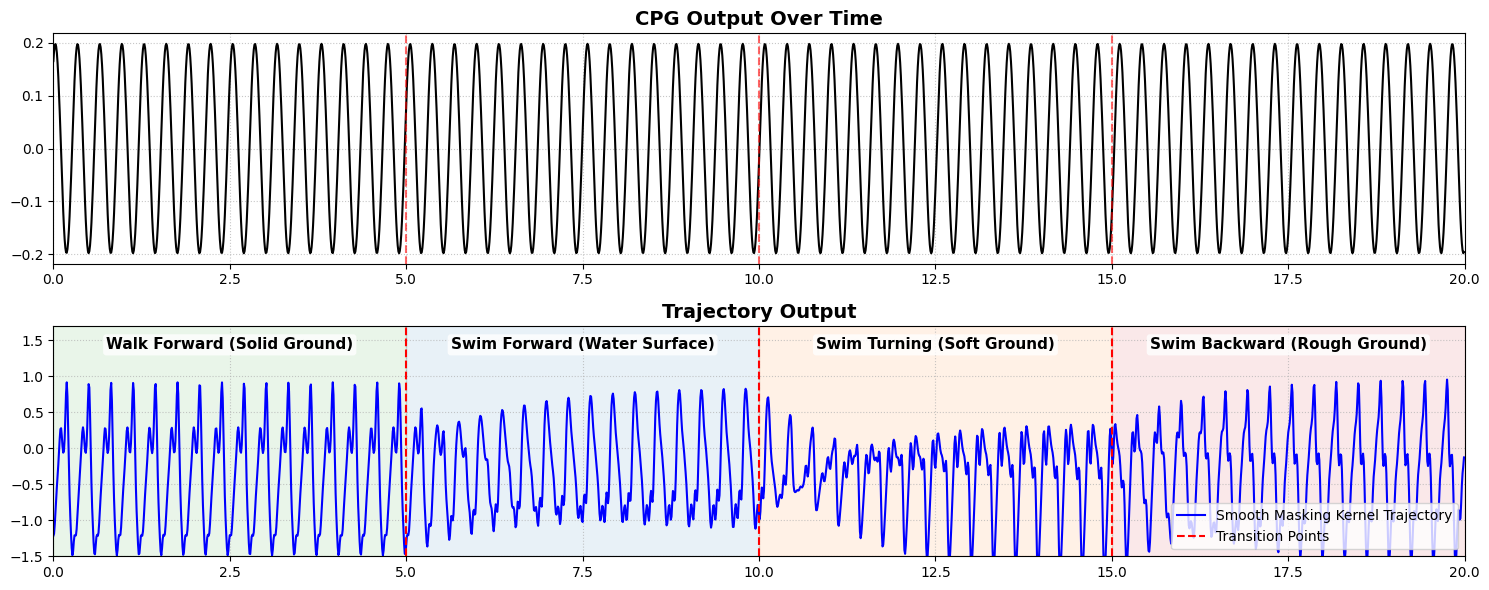

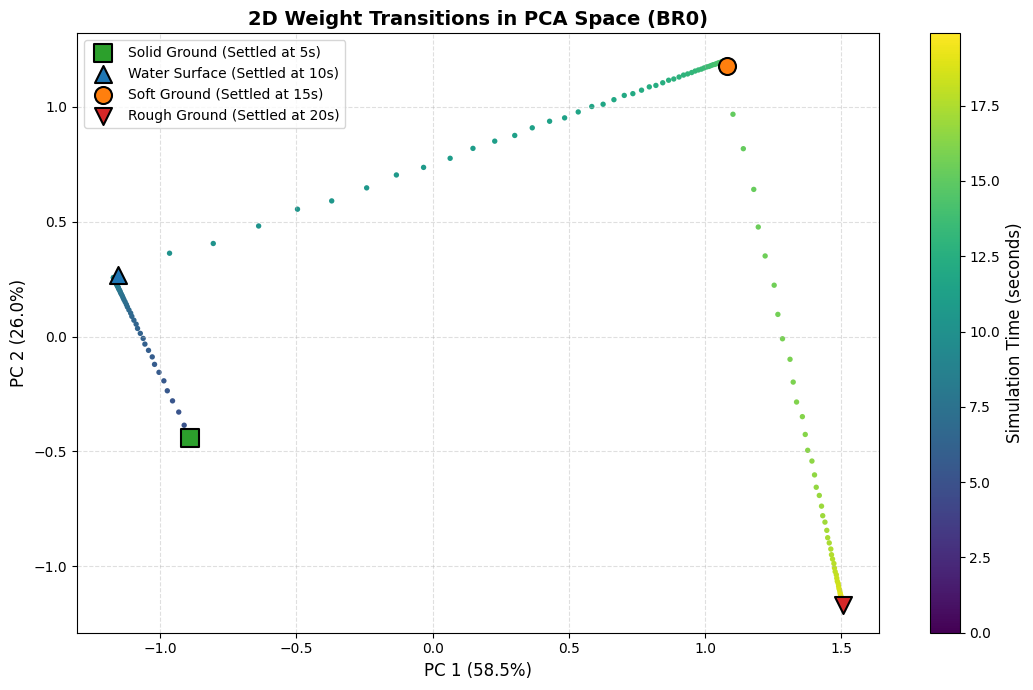

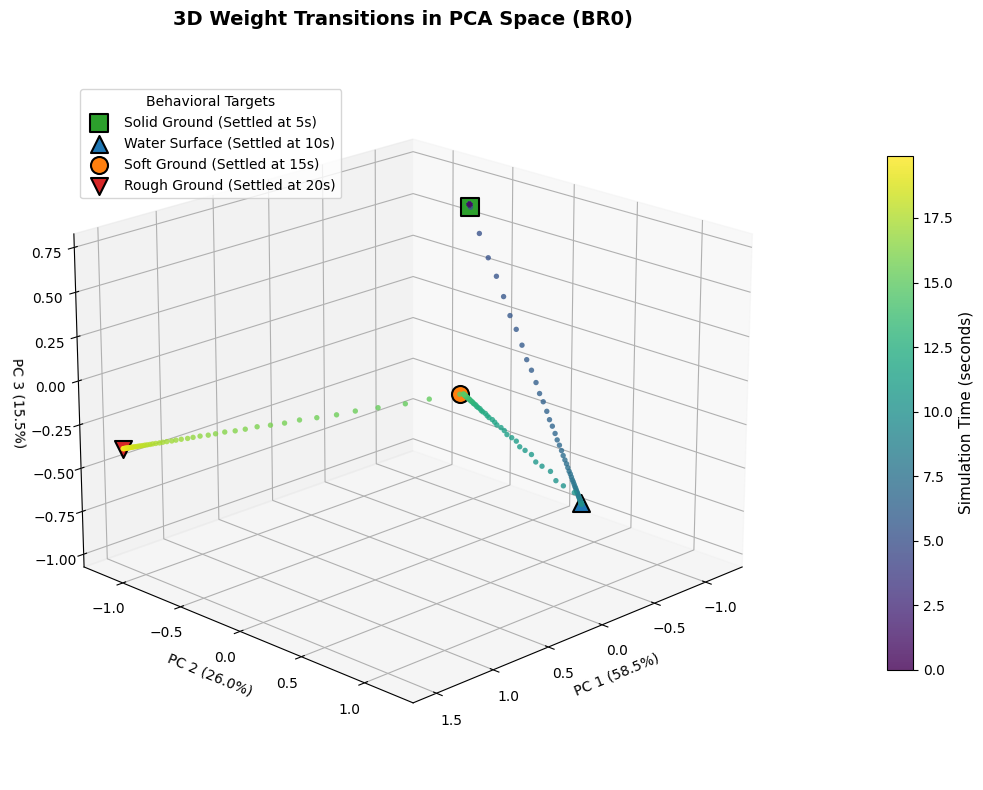

In [33]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D # Needed for 3D projection in some matplotlib versions

# Assuming these are available in your workspace
from cpg_rbf.cpg_so2 import CPG_SO2, CPG_LOCO
from cpg_rbf.rbf import RBF

# ======================================================
# 1. HELPER: LOAD JSON WEIGHTS
# ======================================================
def load_json_weights(filepath):
    try:
        with open(filepath, 'r') as f:
            raw_weights = json.load(f)
        return {k: np.array(v) for k, v in raw_weights.items()}
    except FileNotFoundError:
        print(f"Error: {filepath} not found.")
        return None

# Load the weights for 4 distinct environments
weights_solid = load_json_weights('learned_weight_set/solid_ground/learned_weights.json')
weights_water = load_json_weights('learned_weight_set/water_surface/learned_weights.json')
weights_soft  = load_json_weights('learned_weight_set/soft_ground/learned_weights.json')
weights_rough = load_json_weights('learned_weight_set/rough_ground/learned_weights.json')

JOINT_TO_TRACK = 'BR0'

# ======================================================
# 2. INITIALIZE NEURAL NETWORKS
# ======================================================
NUM_KERNELS = 20
CPG_PHI = 0.2 # Updated to match your new snippet

cpg = CPG_SO2()
rbf = RBF(nc=NUM_KERNELS)

cpg_one_cycle = cpg.generate_cpg_one_cycle(CPG_PHI)
rbf.construct_kernels_with_cpg_one_cycle(
    cpg_one_cycle['out0_cpg_one_cycle'][:], 
    cpg_one_cycle['out1_cpg_one_cycle'][:], 
    len(cpg_one_cycle['out0_cpg_one_cycle'][:])
)

# ======================================================
# 3. SIMULATION SETUP & VARIABLES
# ======================================================
cpg_modulated = CPG_LOCO()

time_list = []
cpg_output_list = []
traj_output_list = []
rbf_weight_list = []  

duration    = 20.0          
frequency   = 100       
dt          = 1.0 / frequency   
total_steps = int(duration * frequency)

# Smoothing State Variables
rbf_weight_prev   = np.copy(weights_solid[JOINT_TO_TRACK])
rbf_weight_target = np.zeros_like(rbf_weight_prev)
rbf_weight_t      = np.zeros_like(rbf_weight_prev)

print("Simulating transitions using smooth gated trajectory...")

# ======================================================
# 4. SIMULATION LOOP 
# ======================================================
for step in range(total_steps):
    sim_time = step * dt
    
    # --------------------------------------------------
    # GAIT TARGET SELECTION
    # --------------------------------------------------
    if sim_time < 5.0:
        rbf_weight_target = weights_solid[JOINT_TO_TRACK]
    elif sim_time < 10.0:
        rbf_weight_target = weights_water[JOINT_TO_TRACK]
    elif sim_time < 15.0:
        rbf_weight_target = weights_soft[JOINT_TO_TRACK]
    else:
        rbf_weight_target = weights_rough[JOINT_TO_TRACK]

    # Step the CPG forward
    cpg_output_t = cpg_modulated.modulate_cpg(CPG_PHI, 0, 1)
    
    # --------------------------------------------------
    # NEW: REGENERATE SMOOTH GATED TRAJECTORY
    # --------------------------------------------------
    traj_output_t, rbf_weight_t = rbf.regenerate_smooth_gated_traj(
        cpg_output_t['cpg_output_0'], 
        cpg_output_t['cpg_output_1'], 
        rbf_weight_prev,
        rbf_weight_target,
        base_alpha=0.01  
    )
    
    # Update previous weight for the next iteration
    rbf_weight_prev = np.copy(rbf_weight_t)

    # STORE DATA (np.copy is CRITICAL for weight histories)
    time_list.append(sim_time)
    cpg_output_list.append(cpg_output_t['cpg_output_0'])
    traj_output_list.append(traj_output_t)
    rbf_weight_list.append(np.copy(rbf_weight_t))

# ======================================================
# 5. PLOT 1: TIME SERIES TRAJECTORY
# ======================================================
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=False)

axs[0].plot(time_list, cpg_output_list, color='black')
axs[0].set_title('CPG Output Over Time', fontsize=14, fontweight='bold')
axs[0].set_xlim(0, duration)
axs[0].grid(True, linestyle=':', alpha=0.7)

axs[1].set_title('Trajectory Output', fontsize=14, fontweight='bold')
axs[1].plot(time_list, traj_output_list, label='Smooth Masking Kernel Trajectory', color='blue')

# Apply region shading and text positioning
regions = [
    (2.5, 0.0, 5.0, 'Walk Forward (Solid Ground)', '#2ca02c'),
    (7.5, 5.0, 10.0, 'Swim Forward (Water Surface)', '#1f77b4'),
    (12.5, 10.0, 15.0, 'Swim Turning (Soft Ground)', '#ff7f0e'),
    (17.5, 15.0, 20.0, 'Swim Backward (Rough Ground)', '#d62728')
]

for pt in [5.0, 10.0, 15.0]:
    lbl = 'Transition Points' if pt == 5.0 else ""
    axs[1].axvline(x=pt, color='r', linestyle='--', label=lbl)
    axs[0].axvline(x=pt, color='r', linestyle='--', alpha=0.6)

for x_pos, start_t, end_t, region_name, color in regions:
    # Optional colored background shading
    axs[1].axvspan(start_t, end_t, color=color, alpha=0.10, label='_nolegend_')
    
    # Text alignments per your request
    axs[1].text(
        x=x_pos, 
        y=0.95, 
        s=region_name, 
        transform=axs[1].get_xaxis_transform(), 
        ha='center', 
        va='top',    
        fontsize=11, 
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2') 
    )

axs[1].set_xlim(0, duration)
axs[1].set_ylim(-1.5, 1.7)
axs[1].grid(True, linestyle=':', alpha=0.7)
axs[1].legend(loc='lower right', fontsize=10)

fig.tight_layout()
# plt.savefig(f'adaptive_locomotion_trajectory_plot_2_{JOINT_TO_TRACK}.png', dpi=300)

# ======================================================
# 6. PLOT 2 & 3 SHARED DATA PREP
# ======================================================


rbf_weights_matrix = np.array(rbf_weight_list)
time_np = np.array(time_list)


pca_styles = {
    'Solid Ground':  {'color': '#2ca02c', 'marker': 's'},
    'Water Surface': {'color': '#1f77b4', 'marker': '^'},
    'Soft Ground':   {'color': '#ff7f0e', 'marker': 'o'},
    'Rough Ground':  {'color': '#d62728', 'marker': 'v'}
}

rbf_weights_matrix = np.array(rbf_weight_list)
time_np = np.array(time_list)
pca_transitions = [
    (5, 'Solid Ground'),
    (10, 'Water Surface'),
    (15, 'Soft Ground'),
    (20, 'Rough Ground')
]

# Plot every 10th point (reduces 2000 points down to 200)
ds = 10


# ======================================================
# 7. PLOT 2: 2D PCA TEMPORAL TRANSITION
# ======================================================
print("Calculating 2D and 3D PCA on weight transitions...")
pca_2d = PCA(n_components=2)
rbf_pca_2d = pca_2d.fit_transform(rbf_weights_matrix)

plt.figure(figsize=(11, 7))
scatter_2d = plt.scatter(
    rbf_pca_2d[::ds, 0], 
    rbf_pca_2d[::ds, 1], 
    c=time_np[::ds],    # Use the numpy time array here so we can slice it
    cmap='viridis', 
    s=15, 
    alpha=1.0, 
    edgecolors='none'
)
for t, label in pca_transitions:
    idx = np.abs(time_np - t).argmin()
    plt.scatter(
        rbf_pca_2d[idx, 0], rbf_pca_2d[idx, 1], 
        color=pca_styles[label]['color'], edgecolors='black', linewidths=1.5,
        s=150, marker=pca_styles[label]['marker'], zorder=5, label=f"{label} (Settled at {int(t)}s)"
    )

cbar_2d = plt.colorbar(scatter_2d)
cbar_2d.set_label('Simulation Time (seconds)', fontsize=12)
plt.xlabel(f'PC 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title(f'2D Weight Transitions in PCA Space ({JOINT_TO_TRACK})', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, facecolor='white', loc='best', fontsize=10)
plt.tight_layout()
# plt.savefig(f'rbf_weights_pca_2d_{JOINT_TO_TRACK}.png', dpi=300, bbox_inches='tight')

# ======================================================
# 8. PLOT 3: 3D PCA TEMPORAL TRANSITION
# ======================================================
pca_3d = PCA(n_components=3)
rbf_pca_3d = pca_3d.fit_transform(rbf_weights_matrix)

fig_3d = plt.figure(figsize=(12, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d')

scatter_3d = ax_3d.scatter(
    rbf_pca_3d[::ds, 0], 
    rbf_pca_3d[::ds, 1], 
    rbf_pca_3d[::ds, 2],
    c=time_np[::ds], 
    cmap='viridis', 
    s=15, 
    alpha=0.8, 
    edgecolors='none'
)
cbar_3d = plt.colorbar(scatter_3d, ax=ax_3d, pad=0.1, shrink=0.7)
cbar_3d.set_label('Simulation Time (seconds)', fontsize=11)

for t, label in pca_transitions:
    idx = np.abs(time_np - t).argmin()
    color = pca_styles[label]['color']
    marker_symbol = pca_styles[label]['marker']
    
    ax_3d.scatter(
        rbf_pca_3d[idx, 0], rbf_pca_3d[idx, 1], rbf_pca_3d[idx, 2],
        color=color, marker=marker_symbol, s=150, edgecolors='black', 
        linewidths=1.5, alpha=1.0, zorder=5, label=f"{label} (Settled at {int(t)}s)"
    )

evr = pca_3d.explained_variance_ratio_ * 100
ax_3d.set_xlabel(f'PC 1 ({evr[0]:.1f}%)', fontsize=10)
ax_3d.set_ylabel(f'PC 2 ({evr[1]:.1f}%)', fontsize=10)
ax_3d.set_zlabel(f'PC 3 ({evr[2]:.1f}%)', fontsize=10)
ax_3d.set_title(f'3D Weight Transitions in PCA Space ({JOINT_TO_TRACK})', fontsize=14, fontweight='bold', pad=15)
ax_3d.view_init(elev=20, azim=45) 

ax_3d.legend(
    title="Behavioral Targets", frameon=True, facecolor='white', 
    loc='upper left', bbox_to_anchor=(0.05, 0.95), fontsize=10
)

plt.tight_layout()
# plt.savefig(f'rbf_weights_pca_3d_{JOINT_TO_TRACK}.png', dpi=300, bbox_inches='tight')

print("✅ All 3 plots successfully generated and saved!")
plt.show()

## Plot Compare

Simulating transitions for all 3 trajectory types...


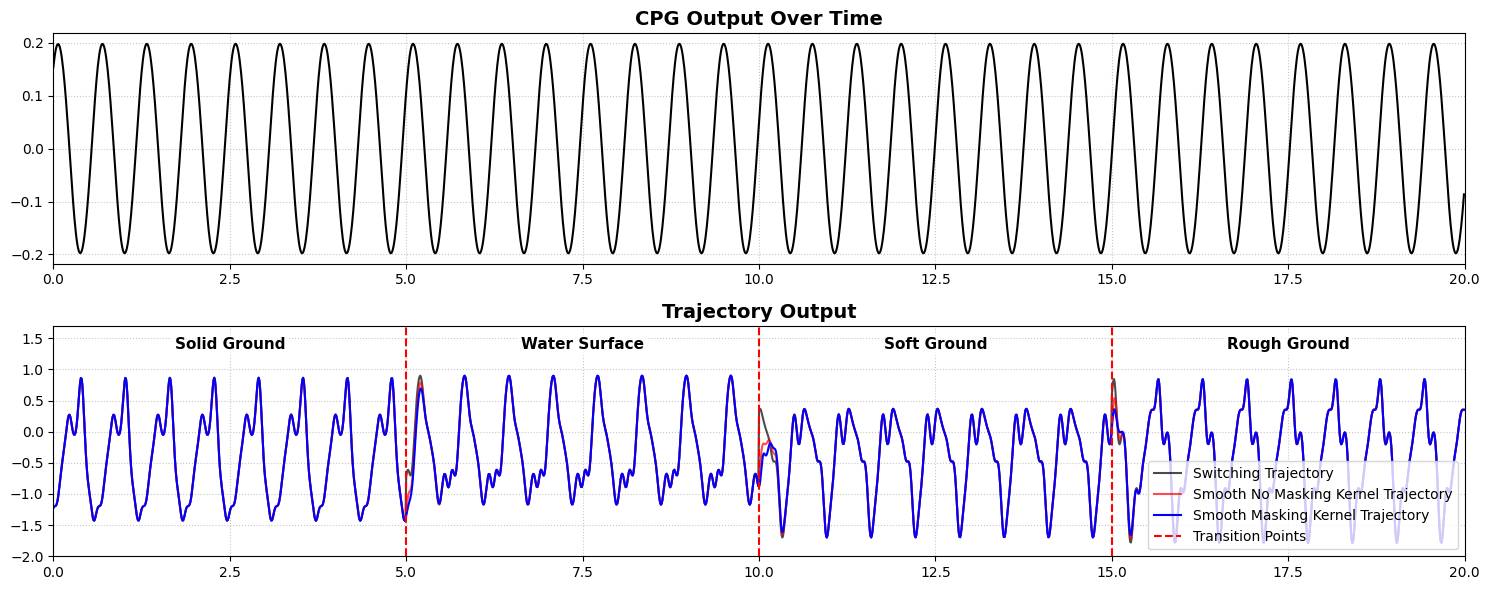

In [29]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Assuming these are available in your workspace
from cpg_rbf.cpg_so2 import CPG_SO2, CPG_LOCO
from cpg_rbf.rbf import RBF

# ======================================================
# 1. HELPER: LOAD JSON WEIGHTS
# ======================================================
def load_json_weights(filepath):
    try:
        with open(filepath, 'r') as f:
            raw_weights = json.load(f)
        return {k: np.array(v) for k, v in raw_weights.items()}
    except FileNotFoundError:
        print(f"Error: {filepath} not found.")
        return None

# Load the weights for 4 distinct environments
weights_solid = load_json_weights('learned_weight_set/solid_ground/learned_weights.json')
weights_water = load_json_weights('learned_weight_set/water_surface/learned_weights.json')
weights_soft  = load_json_weights('learned_weight_set/soft_ground/learned_weights.json')
weights_rough = load_json_weights('learned_weight_set/rough_ground/learned_weights.json')

JOINT_TO_TRACK = 'BR0'

# ======================================================
# 2. INITIALIZE NEURAL NETWORKS
# ======================================================
NUM_KERNELS = 20
CPG_PHI = 0.1 

cpg = CPG_SO2()
rbf = RBF(nc=NUM_KERNELS)

cpg_one_cycle = cpg.generate_cpg_one_cycle(CPG_PHI)
rbf.construct_kernels_with_cpg_one_cycle(
    cpg_one_cycle['out0_cpg_one_cycle'][:], 
    cpg_one_cycle['out1_cpg_one_cycle'][:], 
    len(cpg_one_cycle['out0_cpg_one_cycle'][:])
)

# ======================================================
# 3. SIMULATION SETUP & VARIABLES
# ======================================================
cpg_modulated = CPG_LOCO()

time_list = []
cpg_output_list = []

# Trajectory lists for comparison
traj_output_list = []          # Smooth Masking
traj_output_no_mask_list = []  # Smooth No Masking
traj_output_switch_list = []   # Hard Switch

rbf_weight_list = []  

duration    = 20.0          
frequency   = 100       
dt          = 1.0 / frequency   
total_steps = int(duration * frequency)

# Smoothing State Variables
rbf_weight_prev         = np.copy(weights_solid[JOINT_TO_TRACK])
rbf_weight_no_mask_prev = np.copy(weights_solid[JOINT_TO_TRACK])
rbf_weight_target       = np.zeros_like(rbf_weight_prev)

SMOOTHING_FACTOR = 0.1

print("Simulating transitions for all 3 trajectory types...")

# ======================================================
# 4. SIMULATION LOOP 
# ======================================================
for step in range(total_steps):
    sim_time = step * dt
    
    # GAIT TARGET SELECTION
    if sim_time < 5.0:
        rbf_weight_target = weights_solid[JOINT_TO_TRACK]
    elif sim_time < 10.0:
        rbf_weight_target = weights_water[JOINT_TO_TRACK]
    elif sim_time < 15.0:
        rbf_weight_target = weights_soft[JOINT_TO_TRACK]
    else:
        rbf_weight_target = weights_rough[JOINT_TO_TRACK]

    # Step the CPG forward
    cpg_output_t = cpg_modulated.modulate_cpg(CPG_PHI, 0, 1)
    
    # --- 1. HARD SWITCHING TRAJECTORY ---
    traj_switch_t = rbf.regenerate_target_traj(
        cpg_output_t['cpg_output_0'], 
        cpg_output_t['cpg_output_1'], 
        rbf_weight_target
    )
    
    # --- 2. SMOOTH NO-MASKING TRAJECTORY ---
    rbf_weight_no_mask_t = rbf_weight_no_mask_prev + (rbf_weight_target - rbf_weight_no_mask_prev) * SMOOTHING_FACTOR
    traj_no_mask_t = rbf.regenerate_target_traj(
        cpg_output_t['cpg_output_0'], 
        cpg_output_t['cpg_output_1'], 
        rbf_weight_no_mask_t
    )
    rbf_weight_no_mask_prev = np.copy(rbf_weight_no_mask_t)
    
    # --- 3. SMOOTH MASKING TRAJECTORY (Your new function) ---
    traj_output_t, rbf_weight_t = rbf.regenerate_smooth_gated_traj(
        cpg_output_t['cpg_output_0'], 
        cpg_output_t['cpg_output_1'], 
        rbf_weight_prev,
        rbf_weight_target,
        base_alpha=SMOOTHING_FACTOR  
    )
    rbf_weight_prev = np.copy(rbf_weight_t)

    # STORE DATA 
    time_list.append(sim_time)
    cpg_output_list.append(cpg_output_t['cpg_output_0'])
    
    traj_output_switch_list.append(traj_switch_t)
    traj_output_no_mask_list.append(traj_no_mask_t)
    traj_output_list.append(traj_output_t)
    
    rbf_weight_list.append(np.copy(rbf_weight_t))

# ======================================================
# 5. PLOT 1: TIME SERIES TRAJECTORY (UPDATED)
# ======================================================
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=False)

axs[0].plot(time_list, cpg_output_list, color='black')
axs[0].set_title('CPG Output Over Time', fontsize=14, fontweight='bold')
axs[0].set_xlim(0, duration)
axs[0].grid(True, linestyle=':', alpha=0.7)

axs[1].set_title('Trajectory Output', fontsize=14, fontweight='bold')

# Plot all three trajectory lines
axs[1].plot(time_list, traj_output_switch_list, label='Switching Trajectory', color='black', alpha=0.7)
axs[1].plot(time_list, traj_output_no_mask_list, label='Smooth No Masking Kernel Trajectory', color='red', alpha=0.7)
axs[1].plot(time_list, traj_output_list, label='Smooth Masking Kernel Trajectory', color='blue')

for pt in [5.0, 10.0, 15.0]:
    lbl = 'Transition Points' if pt == 5.0 else ""
    axs[1].axvline(x=pt, color='r', linestyle='--', label=lbl)


regions = [
    (2.5, 'Solid Ground'),
    (7.5, 'Water Surface'),
    (12.5, 'Soft Ground'),
    (17.5, 'Rough Ground')
]

for x_pos, region_name in regions:
    axs[1].text(
        x=x_pos, 
        y=0.95, 
        s=region_name, 
        transform=axs[1].get_xaxis_transform(), 
        ha='center', 
        va='top',    
        fontsize=11, 
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2') 
    )

axs[1].set_xlim(0, duration)
axs[1].set_ylim(-2.0, 1.7)
axs[1].grid(True, linestyle=':', alpha=0.7)
axs[1].legend(loc='lower right', fontsize=10)

fig.tight_layout()
# plt.savefig(f'adaptive_locomotion_trajectory_plot_2_{JOINT_TO_TRACK}.png', dpi=300)
# print(f"✅ Comparison trajectory plot saved to: adaptive_locomotion_trajectory_plot_2_{JOINT_TO_TRACK}.png")

plt.show()